In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-wisconsin-data/data.csv


# Introduction
The data set includes observations labeled as malignant (harmful) or benign (not harmful) cancer type. We'll try to classify labels using support vector machine. 

> Originally published [here](https://github.com/Bhasfe/ml-algorithms/tree/master/SVC)

### What is SVM ?
Support Vector Machines are mainly used for classification problems in Machine Learning. They can also be used for regression problems. A support vector machine tries to find best "hyperplane" which separates different classes. Following figure shows that a hyperplane whose margin is maximized.

<img src="https://github.com/Bhasfe/ml-algorithms/blob/master/SVC/svm.png?raw=true" width="300px" height="300px" align="left" />
<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>
If the classes are not linearly separable, the kernel trick can be applied to make hyperplane. Kernel trick stands for applying the different kernel functions for multidimensional space to get desired dimensions (for example 2D to 3D ). The most populer kernels are RBF (radial basis function), polynomial and linear. Following figure shows us how kernel trick can be applied for 2D space to 3D space transformation

<img src="https://github.com/Bhasfe/ml-algorithms/blob/master/SVC/kernel-trick.png?raw=true" width="500px" height="500px" align="left" />
<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>


# 1. EDA + FE

Firstly, we need to import necessary libraries/packages

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# import Support Vector Classifier
from sklearn.svm import SVC

# for splitting the data into train and test sets
from sklearn.model_selection import train_test_split

# to evaluate the model
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

# I will keep the resulting plots
%matplotlib inline

# Enable Jupyter Notebook's intellisense
%config IPCompleter.greedy=True

Secondly, load the breast cancer dataset and start to explore it.

In [3]:
# Load the data set
breast_cancer = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

# Display first 5 rows of the DataFrame
display(breast_cancer.head())

# Display the statistics
display(breast_cancer.describe())

# Print info
print(breast_cancer.info())


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Notes:
   * There are 569 observations and 33 features.
   * There is no missing values. 
   * **Unnamed: 32** and **id** columns should be dropped

Let's drop the **Unnamed: 32** and the **id** columns

In [4]:
# Drop the columns
breast_cancer.drop(["Unnamed: 32","id"], axis=1, inplace=True)

Count the labels.

B    357
M    212
Name: diagnosis, dtype: int64


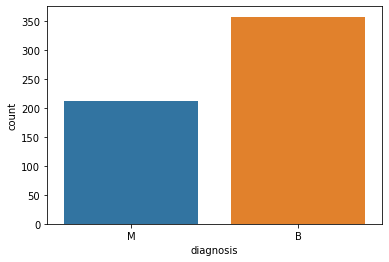

In [5]:
# Print the counts
print(breast_cancer["diagnosis"].value_counts())

# Visualize the counts
sns.countplot(breast_cancer["diagnosis"])
plt.show()

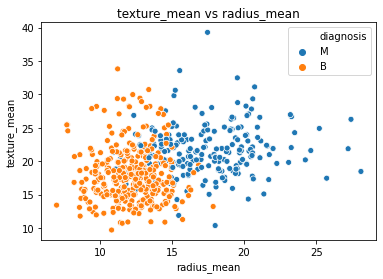

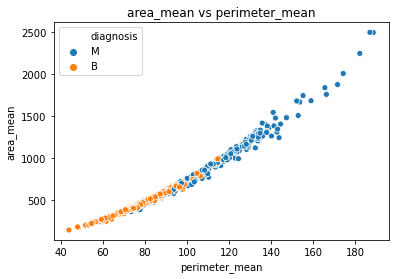

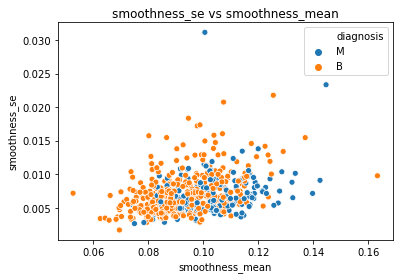

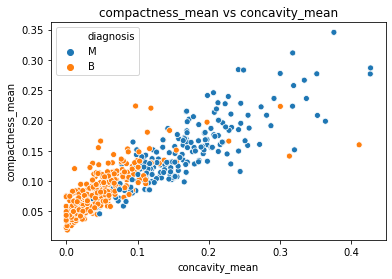

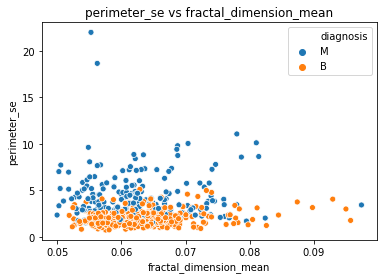

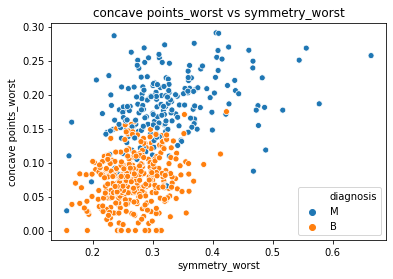

In [6]:
# Visualize some 2-D features to see patterns
def make_scatterplot(x,y):
    sns.scatterplot(x,y,data=breast_cancer,hue='diagnosis')
    plt.title(y + " vs " + x)
    plt.show()
    
make_scatterplot('radius_mean', 'texture_mean')
make_scatterplot('perimeter_mean', 'area_mean')
make_scatterplot('smoothness_mean', 'smoothness_se')
make_scatterplot('concavity_mean', 'compactness_mean')
make_scatterplot('fractal_dimension_mean', 'perimeter_se')
make_scatterplot('symmetry_worst', 'concave points_worst')

Let's look at the correlations.

In [7]:
# Print the correlation matrix
print(breast_cancer.corr())

                         radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean                 1.000000      0.323782        0.997855   0.987357   
texture_mean                0.323782      1.000000        0.329533   0.321086   
perimeter_mean              0.997855      0.329533        1.000000   0.986507   
area_mean                   0.987357      0.321086        0.986507   1.000000   
smoothness_mean             0.170581     -0.023389        0.207278   0.177028   
compactness_mean            0.506124      0.236702        0.556936   0.498502   
concavity_mean              0.676764      0.302418        0.716136   0.685983   
concave points_mean         0.822529      0.293464        0.850977   0.823269   
symmetry_mean               0.147741      0.071401        0.183027   0.151293   
fractal_dimension_mean     -0.311631     -0.076437       -0.261477  -0.283110   
radius_se                   0.679090      0.275869        0.691765   0.732562   
texture_se                 -

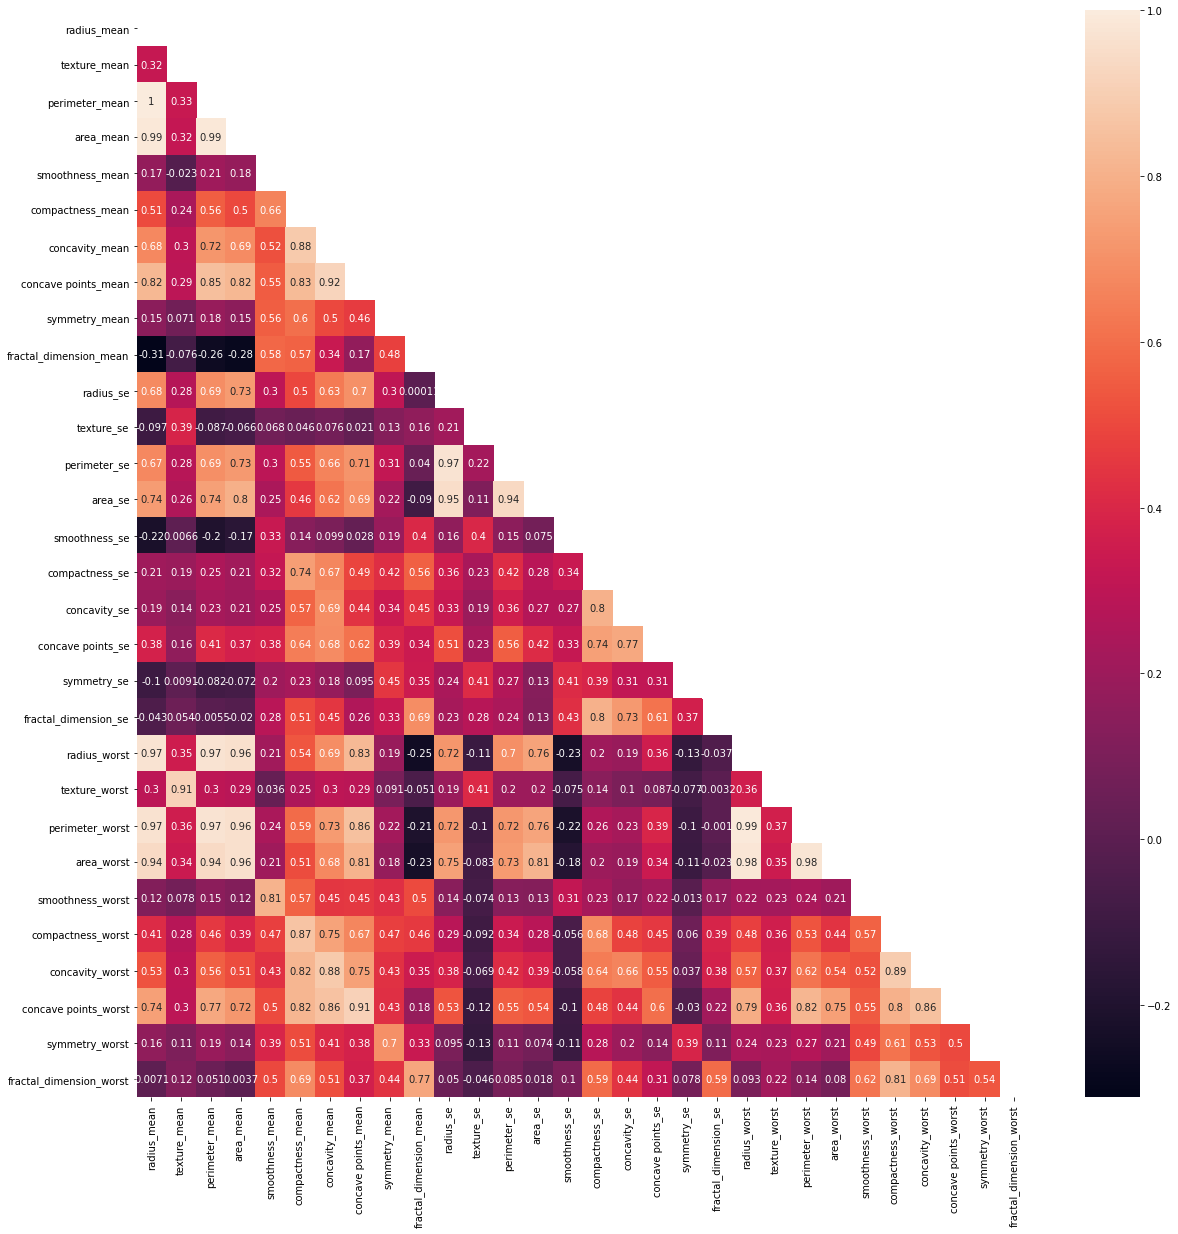

In [8]:
# Visualize with a heatmap
figure, ax = plt.subplots(figsize=(20,20))
mask = np.triu(np.ones_like(breast_cancer.corr(), dtype=np.bool))
sns.heatmap(breast_cancer.corr(), mask=mask, annot=True)
plt.show()

Look at the distributions of some features.

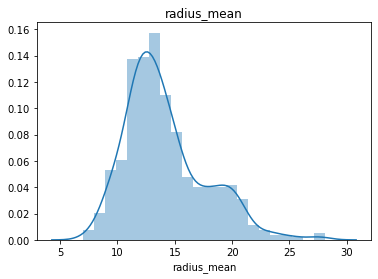

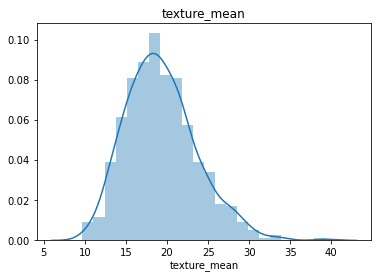

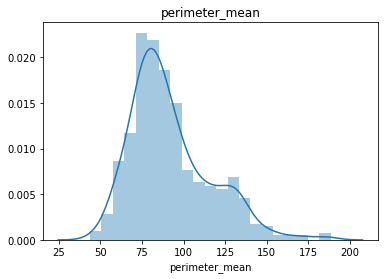

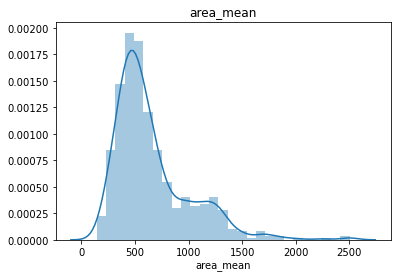

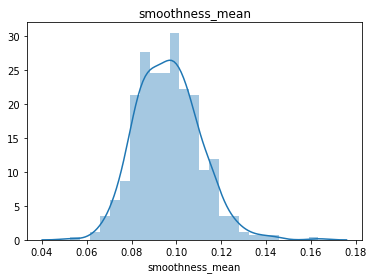

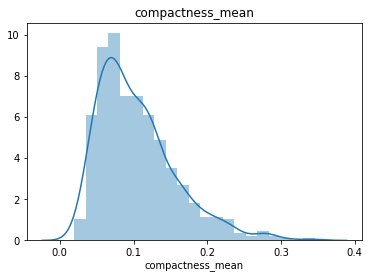

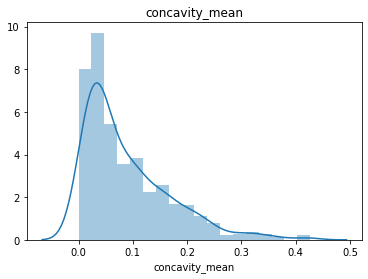

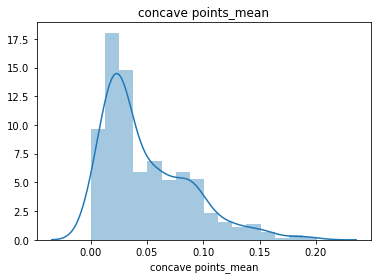

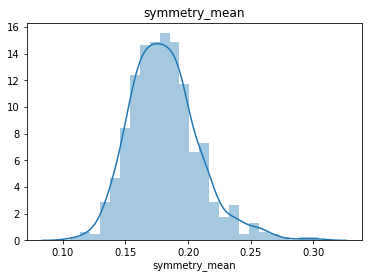

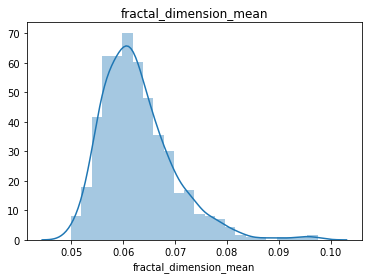

In [9]:
# Plot the histograms
def plot_histogram(column):
    sns.distplot(breast_cancer[column])
    plt.title(column)
    plt.show()


plot_histogram("radius_mean")
plot_histogram("texture_mean")
plot_histogram("perimeter_mean")
plot_histogram("area_mean")
plot_histogram("smoothness_mean")
plot_histogram("compactness_mean")
plot_histogram("concavity_mean")
plot_histogram("concave points_mean")
plot_histogram("symmetry_mean")
plot_histogram("fractal_dimension_mean")


Let's apply dimensionality reduction with t-SNE (t-distributed stochastic neighbor embedding) to see whole picture in 2-D space

Before: (569, 31)
After (569, 2)


,x,y
0,11.485537,31.622038
1,9.412795,29.760143
2,11.025939,25.110579
3,-18.168465,-14.009137
4,13.309860,24.587734


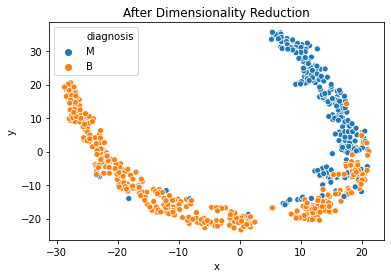

In [10]:
# import TSNE
from sklearn.manifold import TSNE

# fit and transform the TSNE model
tsne = TSNE(learning_rate =  50)
tsne_f = tsne.fit_transform(breast_cancer.drop("diagnosis", axis=1))

# Create a new DataFrame to store reduced features
df = pd.DataFrame({'x':tsne_f[:,0],'y':tsne_f[:,1]})

print("Before:",breast_cancer.shape)
print("After",df.shape)

display(df.head())
sns.scatterplot(x='x', y='y', hue=breast_cancer['diagnosis'],data=df)
plt.title("After Dimensionality Reduction")
plt.show()

Now, it gives us better understanding of the features

# 2. Machine Learning

Select the features and the target.

In [11]:
# Get features and the target
X = breast_cancer.drop("diagnosis", axis=1)
y = breast_cancer["diagnosis"]

Now it's time to build a machine learning model. First of all, we'll split the data into training and test sets.

In [12]:
# Split the data as 30% test and 80% training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=34)

Now we can build our model and make predictions on test set

In [13]:
# Initialize the Support vector classifier
svc = SVC(kernel="linear")

# Fit the SVC with training sets
svc.fit(X_train, y_train)

scores = cross_val_score(svc, X_train, y_train, cv=10, scoring='f1_macro')

print(scores)


[1.         0.93218673 0.97694236 0.97739558 0.95208333 0.90301724
 0.90301724 0.97607656 0.92822967 0.9537037 ]


Let's look at the accuracy score and classification report

In [14]:
# Make predictions on test set
y_pred = svc.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:",acc)

print("\n Classification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

 Classification Report

              precision    recall  f1-score   support

           B       0.97      0.99      0.98        76
           M       0.97      0.95      0.96        38

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



It looks like our model works pretty well! <br>
That's the end of the notebook. I am hoping that it will be helpful to understand basics of SVM.
